# Requirements

In [9]:
# pandas
# textstat
# matplotlib

# Imports

In [10]:
import pandas as pd
import textstat
import matplotlib.pyplot as plt

# Understandability

## Rating

In [5]:
import pandas as pd
import textstat

# Use the raw GitHub CSV link
csv_url = "https://raw.githubusercontent.com/Jeffateth/AI4Good/799bb87b69ba163d9cf2e467e145ccf519729e61/initial_prompts_with_responses_gpt.csv"

# Load CSV from GitHub
df = pd.read_csv(csv_url)
print(df)

# Compute readability scores for each AI response
df["flesch_reading_ease"] = df["Model Response"].apply(textstat.flesch_reading_ease)
df["fk_grade"] = df["Model Response"].apply(textstat.flesch_kincaid_grade)
df["gunning_fog_index"] = df["Model Response"].apply(textstat.gunning_fog)
df["smog_index"] = df["Model Response"].apply(textstat.smog_index)
df["dale_chall_score"] = df["Model Response"].apply(textstat.dale_chall_readability_score)
df["coleman_liau_index"] = df["Model Response"].apply(textstat.coleman_liau_index)

# Save to a new CSV locally
output_file = "gpt_responses_with_readability.csv"
df.to_csv(output_file, index=False)

print(f"✅ Readability scores added and saved to: {output_file}")


# Use the raw GitHub CSV link for Claude data
csv_url = "https://raw.githubusercontent.com/Jeffateth/AI4Good/799bb87b69ba163d9cf2e467e145ccf519729e61/initial_prompts_with_responses_claude.csv"

# Load CSV from GitHub
df = pd.read_csv(csv_url)
print(df)

# Compute readability scores for each AI response
df["flesch_reading_ease"] = df["Model Response"].apply(textstat.flesch_reading_ease)
df["fk_grade"] = df["Model Response"].apply(textstat.flesch_kincaid_grade)
df["gunning_fog_index"] = df["Model Response"].apply(textstat.gunning_fog)
df["smog_index"] = df["Model Response"].apply(textstat.smog_index)
df["dale_chall_score"] = df["Model Response"].apply(textstat.dale_chall_readability_score)
df["coleman_liau_index"] = df["Model Response"].apply(textstat.coleman_liau_index)

# Save to a new CSV locally
output_file = "claude_responses_with_readability.csv"
df.to_csv(output_file, index=False)

print(f"✅ Readability scores added and saved to: {output_file}")


     Prompt Number  age ethnicity  gender                     education  \
0                1   75  European  female  high school diploma or lower   
1                2   50   African    male                medical degree   
2                3   50   African  female                medical degree   
3                4   12   African  female  high school diploma or lower   
4                5   70  European    male                medical degree   
..             ...  ...       ...     ...                           ...   
151            152   50     Asian    male             university degree   
152            153   30  European  female                medical degree   
153            154   80     Asian    male             university degree   
154            155   50  European  female                medical degree   
155            156   60  European  female  high school diploma or lower   

                          diagnosis  \
0                 pancreatic cancer   
1    Chronic Ischemic

## Visualization

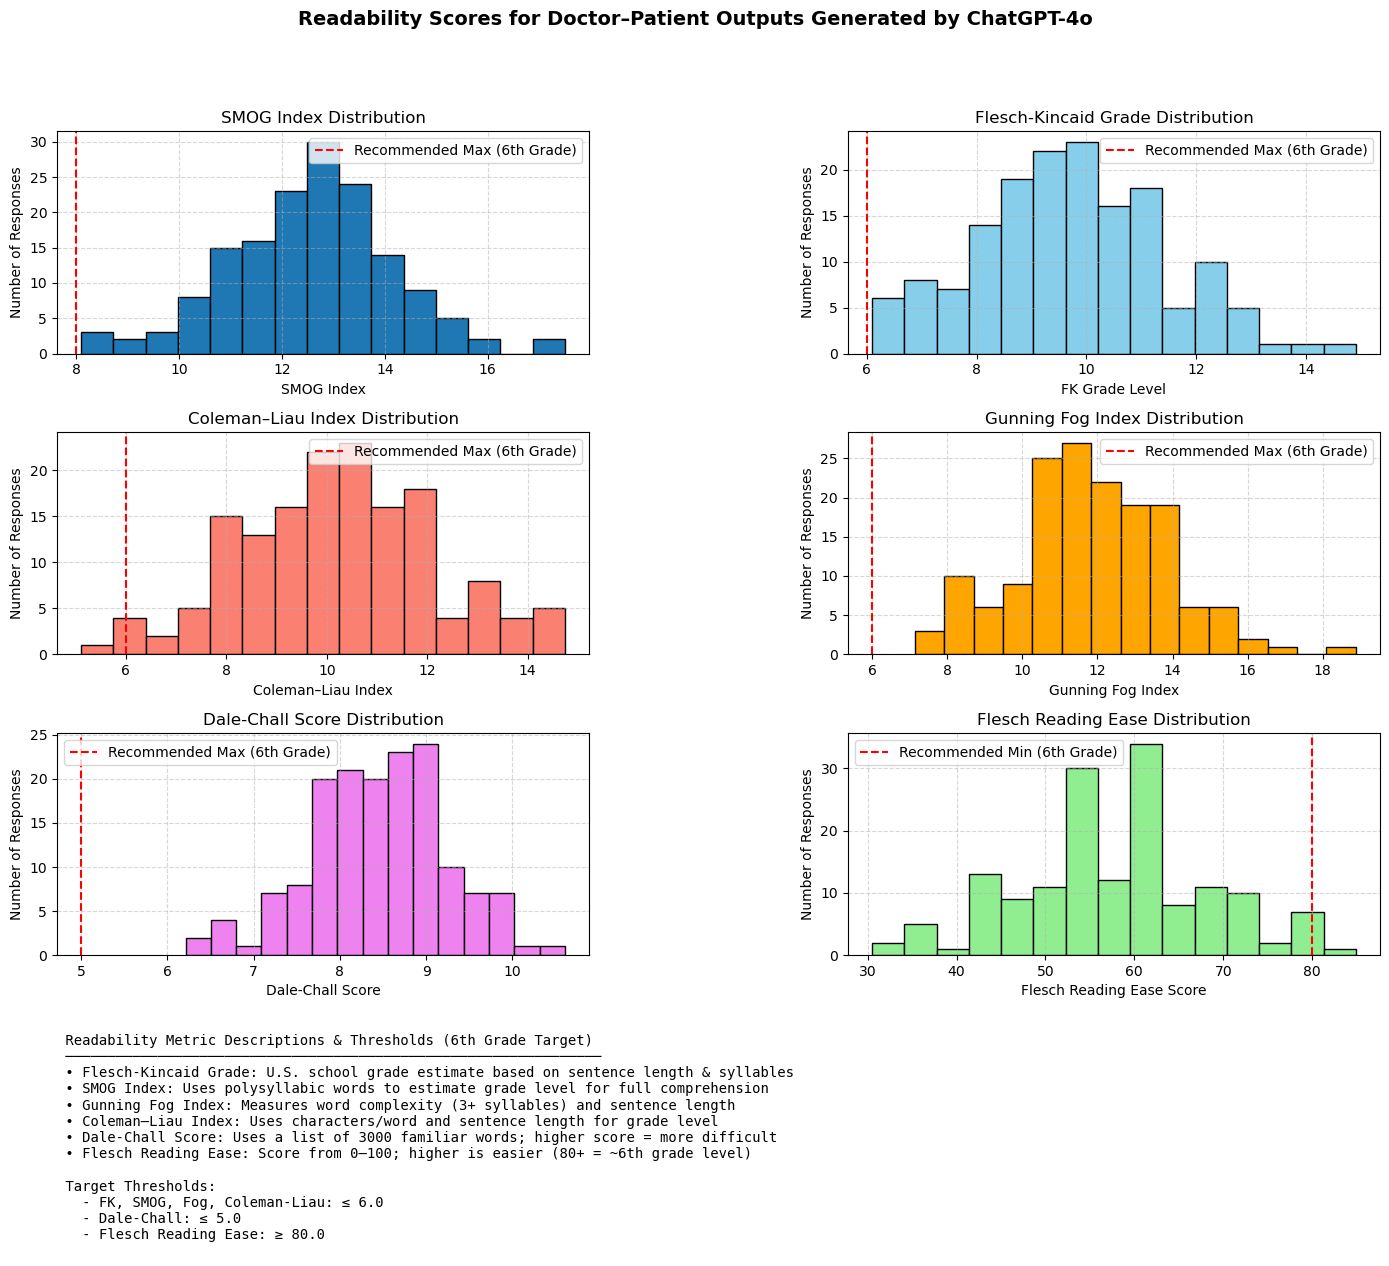

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("gpt_responses_with_readability.csv")

# Create the figure with extra height for the legend
plt.figure(figsize=(14, 13))

# Overall title
plt.suptitle(
    "Readability Scores for Doctor–Patient Outputs Generated by ChatGPT-4o",
    fontsize=14, fontweight='bold', y=1.01
)

# --- Plot 1: SMOG Index ---
plt.subplot(4, 2, 1)
plt.hist(df["smog_index"], bins=15, edgecolor="black")
plt.axvline(x=8, color="red", linestyle="--", label="Recommended Max (6th Grade)")
plt.title("SMOG Index Distribution")
plt.xlabel("SMOG Index")
plt.ylabel("Number of Responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# --- Plot 2: Flesch-Kincaid Grade ---
plt.subplot(4, 2, 2)
plt.hist(df["fk_grade"], bins=15, edgecolor="black", color="skyblue")
plt.axvline(x=6, color="red", linestyle="--", label="Recommended Max (6th Grade)")
plt.title("Flesch-Kincaid Grade Distribution")
plt.xlabel("FK Grade Level")
plt.ylabel("Number of Responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()


# --- Plot 6: Coleman-Liau Index ---
plt.subplot(4, 2, 3)
plt.hist(df["coleman_liau_index"], bins=15, edgecolor="black", color="salmon")
plt.axvline(x=6, color="red", linestyle="--", label="Recommended Max (6th Grade)")
plt.title("Coleman–Liau Index Distribution")
plt.xlabel("Coleman–Liau Index")
plt.ylabel("Number of Responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# --- Plot 4: Gunning Fog Index ---
plt.subplot(4, 2, 4)
plt.hist(df["gunning_fog_index"], bins=15, edgecolor="black", color="orange")
plt.axvline(x=6, color="red", linestyle="--", label="Recommended Max (6th Grade)")
plt.title("Gunning Fog Index Distribution")
plt.xlabel("Gunning Fog Index")
plt.ylabel("Number of Responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# --- Plot 5: Dale-Chall Readability Score ---
plt.subplot(4, 2, 5)
plt.hist(df["dale_chall_score"], bins=15, edgecolor="black", color="violet")
plt.axvline(x=5.0, color="red", linestyle="--", label="Recommended Max (6th Grade)")
plt.title("Dale-Chall Score Distribution")
plt.xlabel("Dale-Chall Score")
plt.ylabel("Number of Responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()


# --- Plot 3: Flesch Reading Ease ---
plt.subplot(4, 2, 6)
plt.hist(df["flesch_reading_ease"], bins=15, edgecolor="black", color="lightgreen")
plt.axvline(x=80, color="red", linestyle="--", label="Recommended Min (6th Grade)")
plt.title("Flesch Reading Ease Distribution")
plt.xlabel("Flesch Reading Ease Score")
plt.ylabel("Number of Responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
# --- Plot 7: Readability Metric Descriptions ---
plt.subplot(4, 2, 7)
plt.axis("off")
description_text = (
    " Readability Metric Descriptions & Thresholds (6th Grade Target)\n"
    " ────────────────────────────────────────────────────────────────\n"
    " • Flesch-Kincaid Grade: U.S. school grade estimate based on sentence length & syllables\n"
    " • SMOG Index: Uses polysyllabic words to estimate grade level for full comprehension\n"
    " • Gunning Fog Index: Measures word complexity (3+ syllables) and sentence length\n"
    " • Coleman–Liau Index: Uses characters/word and sentence length for grade level\n"
    " • Dale-Chall Score: Uses a list of 3000 familiar words; higher score = more difficult\n"
    " • Flesch Reading Ease: Score from 0–100; higher is easier (80+ = ~6th grade level)\n"
    "\n Target Thresholds:\n"
    "   - FK, SMOG, Fog, Coleman-Liau: ≤ 6.0\n"
    "   - Dale-Chall: ≤ 5.0\n"
    "   - Flesch Reading Ease: ≥ 80.0"
)
plt.text(0, 1, description_text, fontsize=10, verticalalignment='top', family='monospace')

# Adjust layout
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()


## Analysis

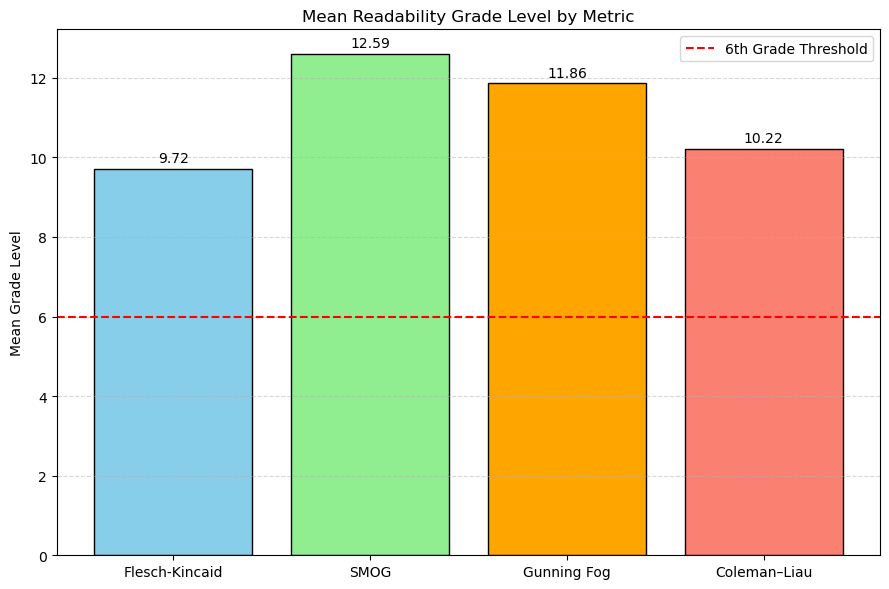

In [30]:
import matplotlib.pyplot as plt

# Calculate mean grade levels
mean_scores = {
    "Flesch-Kincaid": df["fk_grade"].mean(),
    "SMOG": df["smog_index"].mean(),
    "Gunning Fog": df["gunning_fog_index"].mean(),
    "Coleman–Liau": df["coleman_liau_index"].mean()
}

# Create bar plot
plt.figure(figsize=(9, 6))
bars = plt.bar(mean_scores.keys(), mean_scores.values(), 
               color=["skyblue", "lightgreen", "orange", "salmon"], edgecolor="black")

# Add red threshold line at 6th grade
plt.axhline(y=6, color="red", linestyle="--", label="6th Grade Threshold")

# Labels and title
plt.ylabel("Mean Grade Level")
plt.title("Mean Readability Grade Level by Metric")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

# Annotate values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{height:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


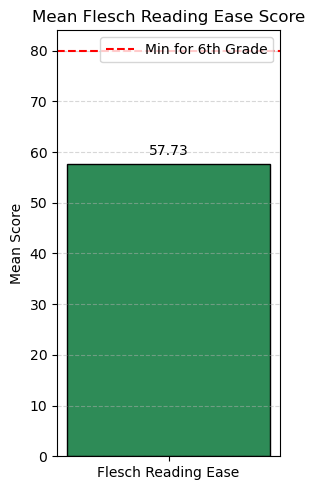

In [24]:
# Flesch Reading Ease mean plot
mean_fre = df["flesch_reading_ease"].mean()

plt.figure(figsize=(3, 5))
bar = plt.bar(["Flesch Reading Ease"], [mean_fre], color="seagreen", edgecolor="black")

# Add threshold line (~6th grade min)
plt.axhline(y=80, color="red", linestyle="--", label="Min for 6th Grade")

plt.ylabel("Mean Score")
plt.title("Mean Flesch Reading Ease Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

# Annotate value
plt.text(0, mean_fre + 1, f"{mean_fre:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


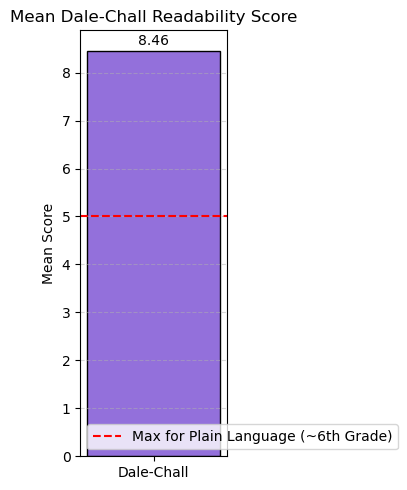

In [23]:
import matplotlib.pyplot as plt

# Compute mean Dale-Chall score
mean_dale_chall = df["dale_chall_score"].mean()

# Create the bar plot
plt.figure(figsize=(3, 5))
bar = plt.bar(["Dale-Chall"], [mean_dale_chall], color="mediumpurple", edgecolor="black")

# Add threshold line for ~6th grade readability
plt.axhline(y=5.0, color="red", linestyle="--", label="Max for Plain Language (~6th Grade)")

# Add labels, grid, and annotation
plt.ylabel("Mean Score")
plt.title("Mean Dale-Chall Readability Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

# Annotate value
plt.text(0, mean_dale_chall + 0.05, f"{mean_dale_chall:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


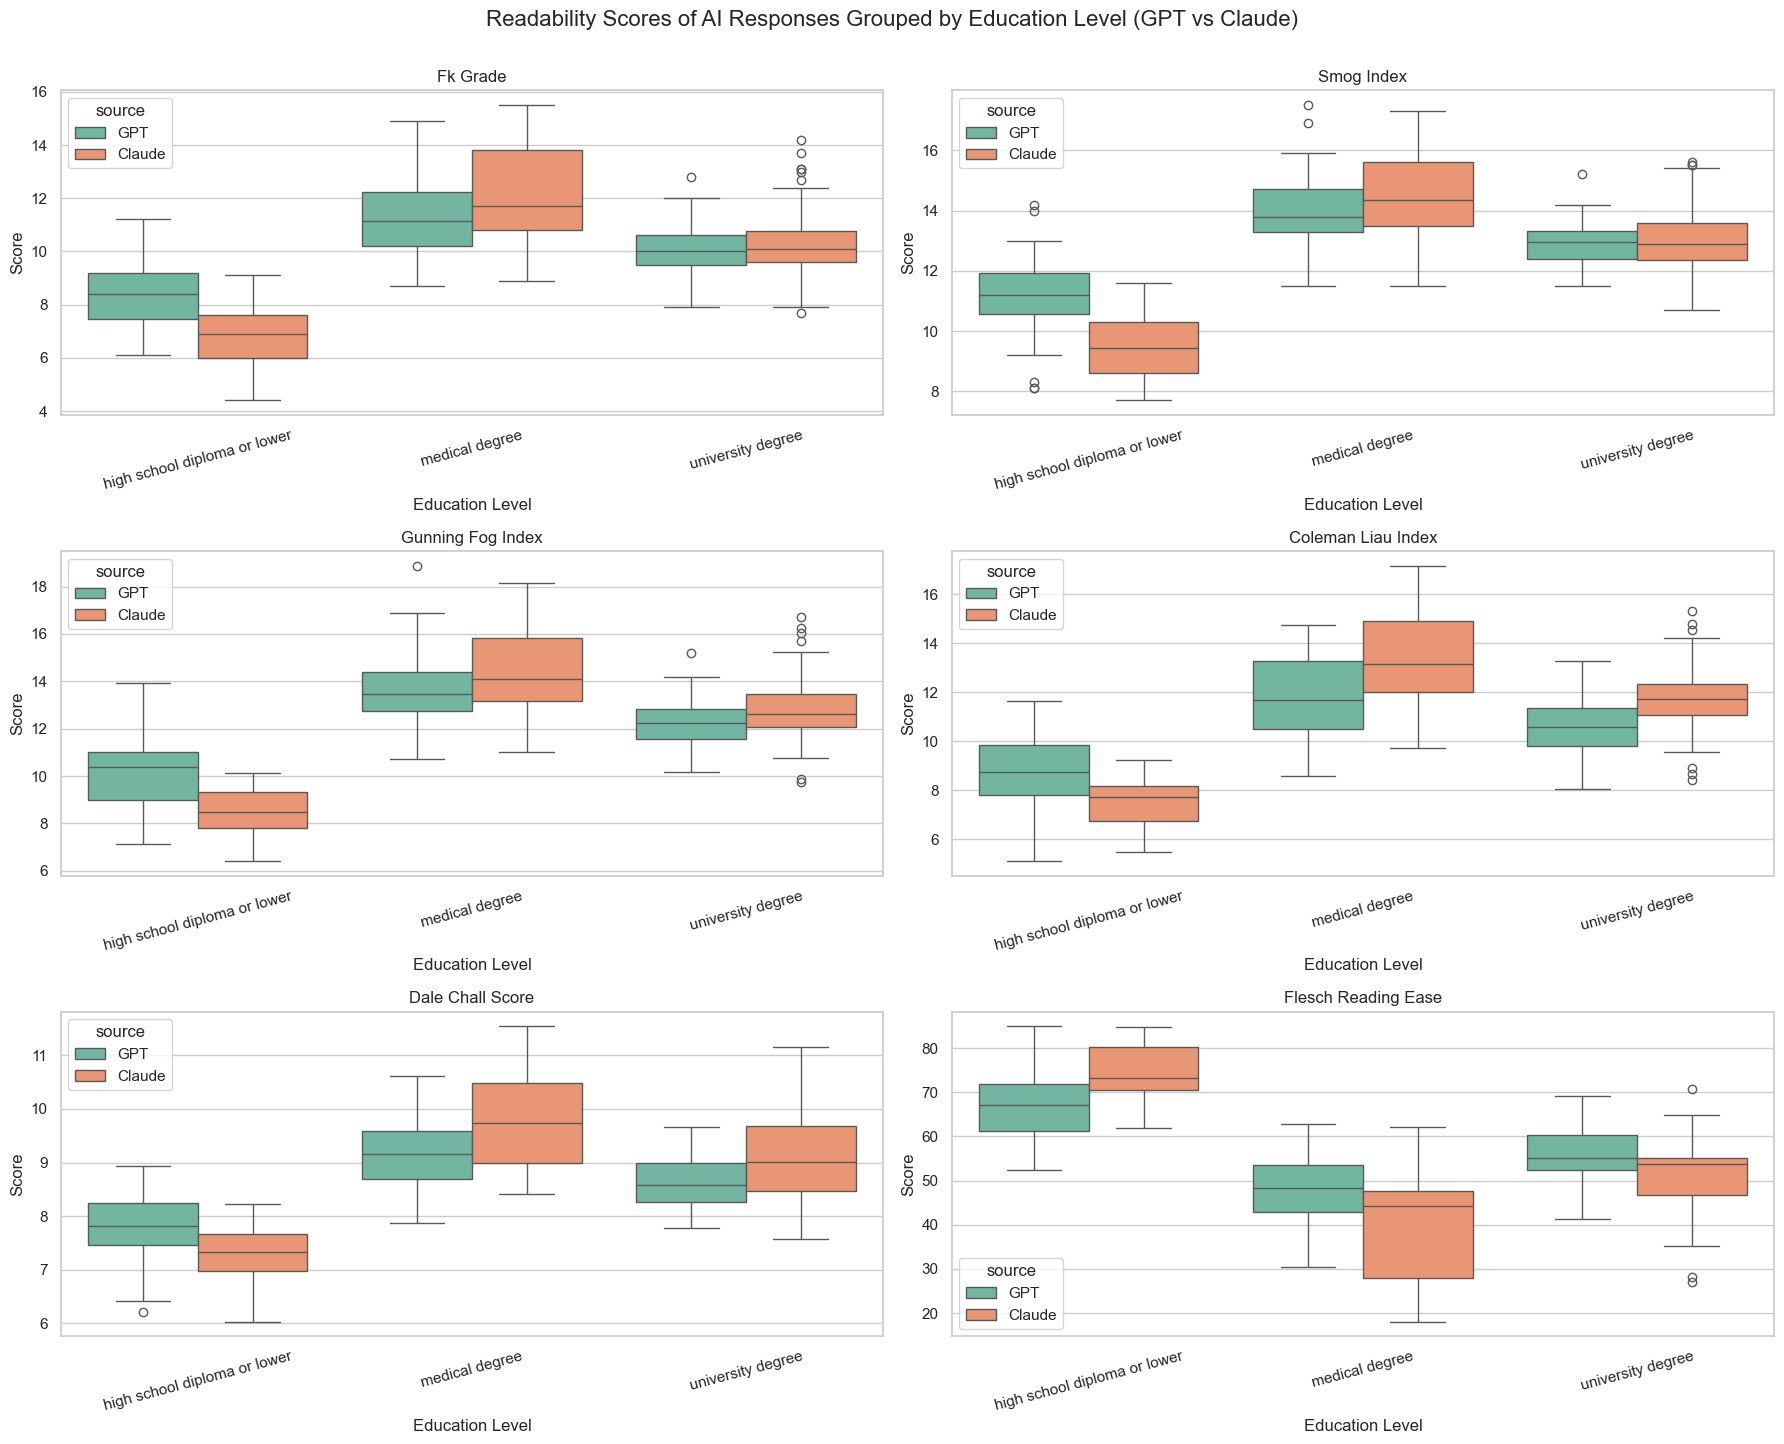

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load GPT and Claude datasets with readability scores
gpt_df = pd.read_csv("gpt_responses_with_readability.csv")
claude_df = pd.read_csv("claude_responses_with_readability.csv")

# Add source identifiers
gpt_df["source"] = "GPT"
claude_df["source"] = "Claude"

# Combine the datasets
df = pd.concat([gpt_df, claude_df], ignore_index=True)

# Set up plot style
sns.set(style="whitegrid")

# Define readability metrics to plot
readability_metrics = [
    "fk_grade",
    "smog_index",
    "gunning_fog_index",
    "coleman_liau_index",
    "dale_chall_score",
    "flesch_reading_ease"
]

# Create subplots for each readability metric
plt.figure(figsize=(18, 14))
for i, metric in enumerate(readability_metrics, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(
        data=df,
        x="education",
        y=metric,
        hue="source",  # Show GPT vs Claude comparison
        palette="Set2"
    )
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("Education Level")
    plt.ylabel("Score")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.suptitle("Readability Scores of AI Responses Grouped by Education Level (GPT vs Claude)", fontsize=16, y=1.03)
plt.show()
